# ใบงานที่ 6: Neural Network และการประยุกต์ใช้งาน
## Fake Bills Classification (การจำแนกธนบัตรปลอม) ด้วย Neural Network

**Dataset:** [Fake Bills](https://www.kaggle.com/datasets/alexandrepetit881234/fake-bills) — 1,500 ธนบัตร (1,000 ของจริง / 500 ของปลอม) วัดจาก 6 คุณลักษณะทางเรขาคณิตของภาพธนบัตร

**เป้าหมาย:**
1. สร้างและฝึก Neural Network (MLP) เพื่อจำแนกธนบัตรจริง/ปลอม
2. เปรียบเทียบผลลัพธ์เมื่อใช้จำนวน epoch ต่างกัน
3. เปรียบเทียบผลลัพธ์เมื่อใช้โครงสร้าง (จำนวน hidden layer / neuron) ต่างกัน
4. ประเมินผลด้วย Accuracy, Confusion Matrix, Loss curve


In [1]:
# ==== Imports ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, roc_curve, roc_auc_score)
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded.")


Libraries loaded.


## 1. โหลดข้อมูล (Load Dataset)

In [2]:
df = pd.read_csv("data/fake_bills.csv", sep=";")
print("Shape:", df.shape)
df.head()


Shape: (1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


## 2. สำรวจข้อมูลเบื้องต้น (Exploratory Data Analysis)

ตรวจสอบค่าว่าง (missing values) และความสมดุลของ class (`is_genuine`)

In [4]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Class balance (is_genuine):")
print(df["is_genuine"].value_counts())


Missing values per column:
is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64

Class balance (is_genuine):
is_genuine
True     1000
False     500
Name: count, dtype: int64


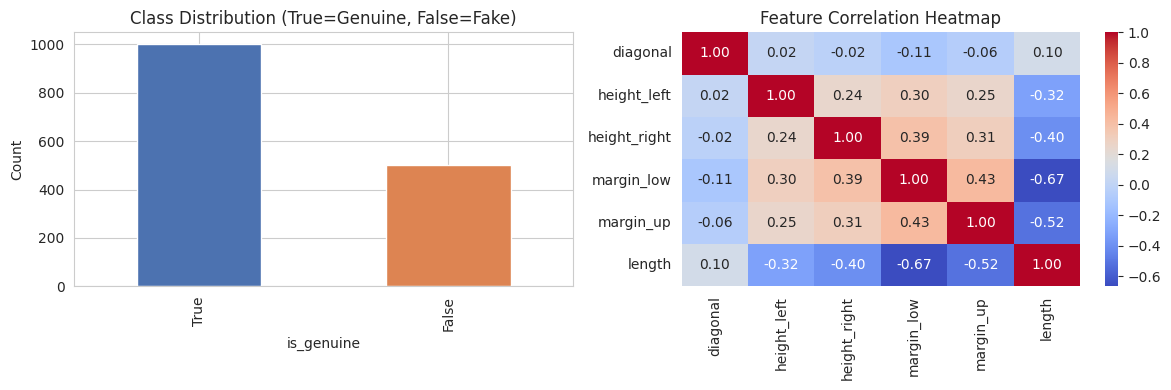

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["is_genuine"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Class Distribution (True=Genuine, False=Fake)")
axes[0].set_xlabel("is_genuine")
axes[0].set_ylabel("Count")

sns.heatmap(df.drop(columns=["is_genuine"]).corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()


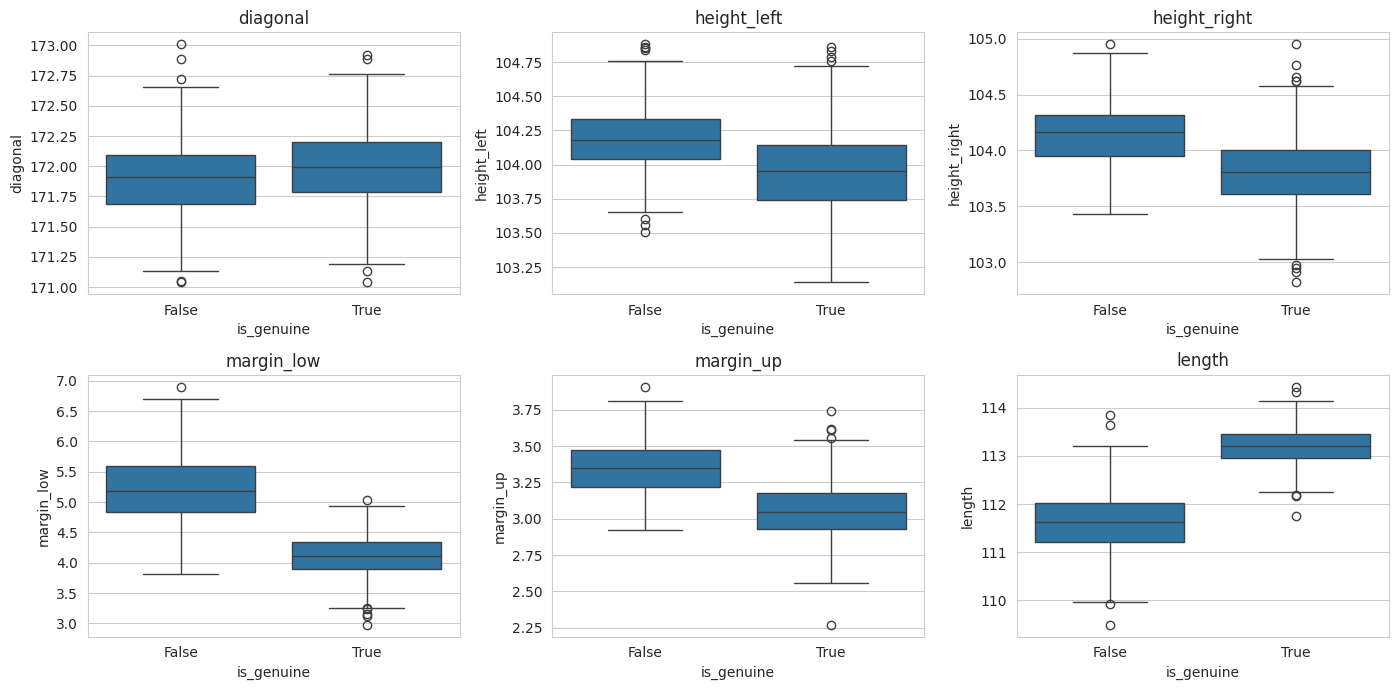

In [6]:
features = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feat in zip(axes.ravel(), features):
    sns.boxplot(data=df, x="is_genuine", y=feat, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()


## 3. การเตรียมข้อมูล (Data Preprocessing)

- คอลัมน์ `margin_low` มีค่าว่างอยู่บางส่วน → เติมด้วยค่ามัธยฐาน (median imputation)
- แปลง target `is_genuine` (True/False) เป็นตัวเลข (1/0)

In [7]:
# Impute missing values in margin_low with the median
imputer = SimpleImputer(strategy="median")
df["margin_low"] = imputer.fit_transform(df[["margin_low"]])

print("Missing values after imputation:")
print(df.isna().sum())

# Encode target: True -> 1 (genuine), False -> 0 (fake)
df["target"] = df["is_genuine"].astype(int)

X = df[features]
y = df["target"]


Missing values after imputation:
is_genuine      0
diagonal        0
height_left     0
height_right    0
margin_low      0
margin_up       0
length          0
dtype: int64


## 4. แบ่งข้อมูล Train / Test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))


Train shape: (1200, 6)  Test shape: (300, 6)
Train class balance:
 target
1    0.666667
0    0.333333
Name: proportion, dtype: float64
Test class balance:
 target
1    0.666667
0    0.333333
Name: proportion, dtype: float64


## 5. การปรับมาตรฐานข้อมูล (Standardization)

Neural Network ไวต่อ scale ของ input มาก จึงต้อง standardize ฟีเจอร์ก่อนนำเข้าโมเดล
(fit scaler บน train set เท่านั้น เพื่อป้องกัน data leakage)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Mean (train, scaled):", np.round(X_train_scaled.mean(axis=0), 3))
print("Std  (train, scaled):", np.round(X_train_scaled.std(axis=0), 3))


Mean (train, scaled): [ 0. -0.  0. -0.  0. -0.]
Std  (train, scaled): [1. 1. 1. 1. 1. 1.]


## 6. สร้าง Neural Network เบื้องต้น (Baseline Model)

ใช้ `MLPClassifier` (Multi-Layer Perceptron) จาก scikit-learn เป็น Neural Network
โครงสร้างเริ่มต้น: 1 hidden layer, 32 neurons, activation ReLU, optimizer Adam

In [10]:
baseline_model = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation="relu",
    solver="adam",
    max_iter=200,
    random_state=RANDOM_STATE
)
baseline_model.fit(X_train_scaled, y_train)

train_acc = accuracy_score(y_train, baseline_model.predict(X_train_scaled))
test_acc = accuracy_score(y_test, baseline_model.predict(X_test_scaled))

print(f"Baseline model  -> Train accuracy: {train_acc:.4f} | Test accuracy: {test_acc:.4f}")


Baseline model  -> Train accuracy: 0.9917 | Test accuracy: 0.9900


## 7. การทดลองที่ 1: เปรียบเทียบจำนวน Epoch (max_iter)

ฝึกโมเดลด้วยโครงสร้างเดิม (1 hidden layer, 32 neurons) แต่เปลี่ยนจำนวน epoch (`max_iter`)
เพื่อดูผลของจำนวนรอบการฝึกต่อ accuracy

In [11]:
epoch_options = [5, 10, 25, 50, 100, 200, 300]
epoch_results = []

for n_epochs in epoch_options:
    model = MLPClassifier(
        hidden_layer_sizes=(32,),
        activation="relu",
        solver="adam",
        max_iter=n_epochs,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_scaled, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))

    epoch_results.append({
        "epochs": n_epochs,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "final_loss": model.loss_,
        "n_iter": model.n_iter_
    })

epoch_df = pd.DataFrame(epoch_results)
epoch_df


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


,epochs,train_accuracy,test_accuracy,final_loss,n_iter
0,5,0.757500,0.756667,0.516422,5
1,10,0.930000,0.923333,0.367123,10
2,25,0.981667,0.983333,0.153995,25
3,50,0.990000,0.983333,0.066815,50
4,100,0.990833,0.990000,0.034698,100
5,200,0.991667,0.990000,0.026927,156
6,300,0.991667,0.990000,0.026927,156


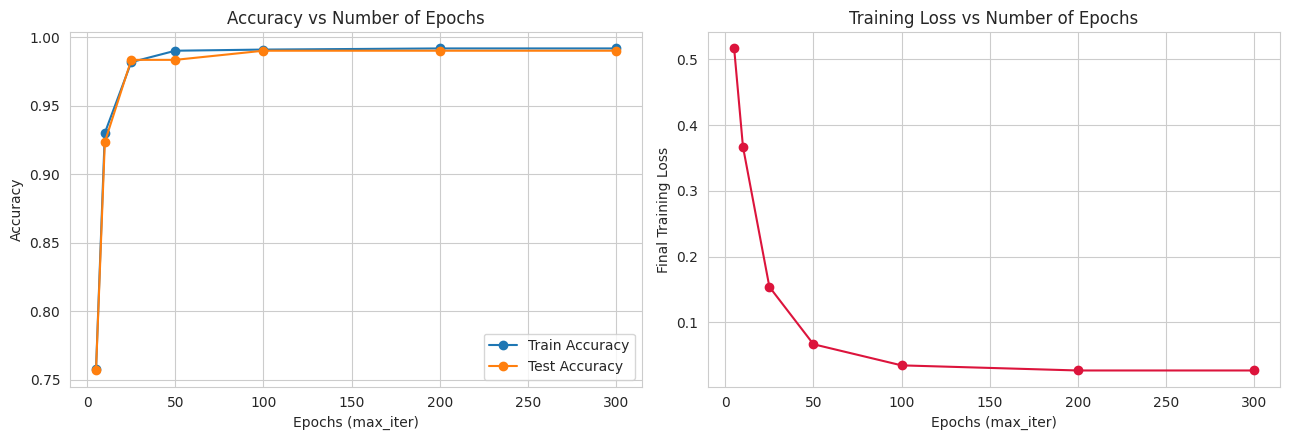

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epoch_df["epochs"], epoch_df["train_accuracy"], marker="o", label="Train Accuracy")
axes[0].plot(epoch_df["epochs"], epoch_df["test_accuracy"], marker="o", label="Test Accuracy")
axes[0].set_xlabel("Epochs (max_iter)")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs Number of Epochs")
axes[0].legend()

axes[1].plot(epoch_df["epochs"], epoch_df["final_loss"], marker="o", color="crimson")
axes[1].set_xlabel("Epochs (max_iter)")
axes[1].set_ylabel("Final Training Loss")
axes[1].set_title("Training Loss vs Number of Epochs")

plt.tight_layout()
plt.show()


## 8. การทดลองที่ 2: เปรียบเทียบโครงสร้าง Neural Network

ตรึงจำนวน epoch ไว้ที่ 200 แล้วเปรียบเทียบจำนวน hidden layer และจำนวน neuron ต่างกัน

In [13]:
architectures = {
    "1 layer - 8 neurons":         (8,),
    "1 layer - 32 neurons":        (32,),
    "1 layer - 64 neurons":        (64,),
    "2 layers - (32, 16)":         (32, 16),
    "2 layers - (64, 32)":         (64, 32),
    "3 layers - (64, 32, 16)":     (64, 32, 16),
}

arch_results = []
trained_models = {}

for name, layers in architectures.items():
    model = MLPClassifier(
        hidden_layer_sizes=layers,
        activation="relu",
        solver="adam",
        max_iter=200,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))

    arch_results.append({
        "architecture": name,
        "hidden_layers": len(layers),
        "total_neurons": sum(layers),
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "final_loss": model.loss_
    })

arch_df = pd.DataFrame(arch_results).sort_values("test_accuracy", ascending=False).reset_index(drop=True)
arch_df


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,architecture,hidden_layers,total_neurons,train_accuracy,test_accuracy,final_loss
0,1 layer - 8 neurons,1,8,0.990833,0.993333,0.057853
1,1 layer - 32 neurons,1,32,0.991667,0.990000,0.026927
2,1 layer - 64 neurons,1,64,0.992500,0.986667,0.024128
3,"2 layers - (32, 16)",2,48,0.994167,0.986667,0.018167
4,"2 layers - (64, 32)",2,96,0.999167,0.983333,0.005185
5,"3 layers - (64, 32, 16)",3,112,0.999167,0.973333,0.002613


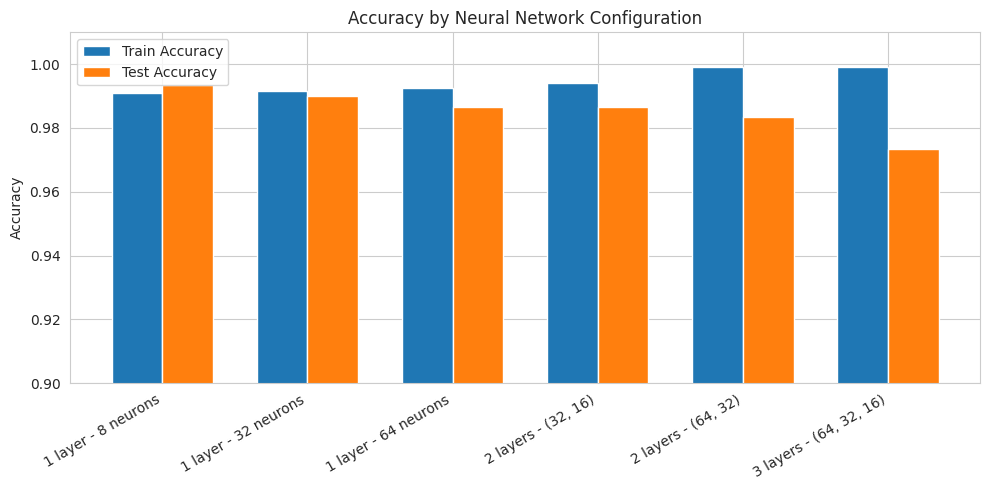

In [14]:
plt.figure(figsize=(10, 5))
x = np.arange(len(arch_df))
width = 0.35

plt.bar(x - width/2, arch_df["train_accuracy"], width, label="Train Accuracy")
plt.bar(x + width/2, arch_df["test_accuracy"], width, label="Test Accuracy")
plt.xticks(x, arch_df["architecture"], rotation=30, ha="right")
plt.ylabel("Accuracy")
plt.title("Accuracy by Neural Network Configuration")
plt.ylim(0.9, 1.01)
plt.legend()
plt.tight_layout()
plt.show()


## 9. เลือกโมเดลที่ดีที่สุด และประเมินผลอย่างละเอียด (Best Model Evaluation)

In [15]:
best_arch_name = arch_df.iloc[0]["architecture"]
best_layers = architectures[best_arch_name]
print(f"Best architecture: {best_arch_name} -> hidden_layer_sizes={best_layers}")

best_model = MLPClassifier(
    hidden_layer_sizes=best_layers,
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=RANDOM_STATE
)
best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Fake (0)", "Genuine (1)"]))


Best architecture: 1 layer - 8 neurons -> hidden_layer_sizes=(8,)



Final Test Accuracy: 0.9900

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.98      0.99      0.99       100
 Genuine (1)       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


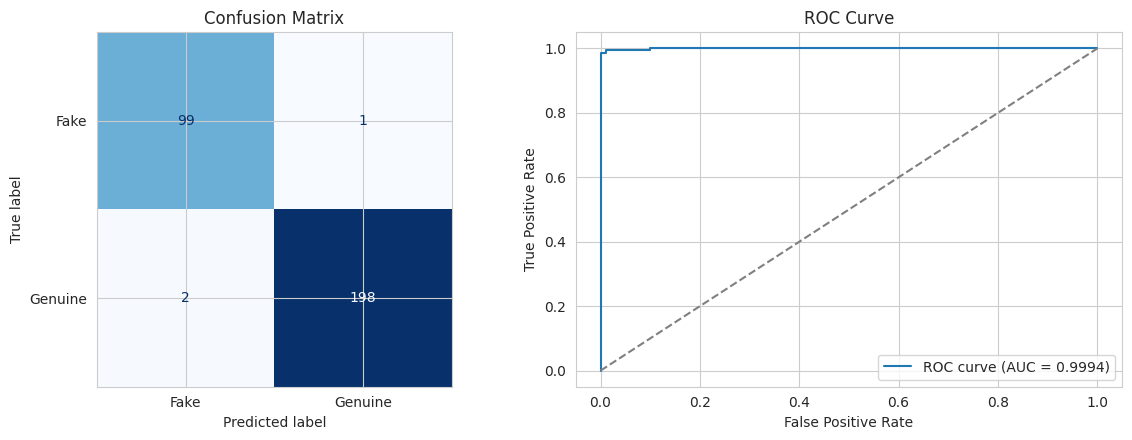

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Fake", "Genuine"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.4f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()


## 10. Training / Validation Loss & Accuracy Curve ของโมเดลที่ดีที่สุด

ใช้ `early_stopping=True` เพื่อให้ scikit-learn แบ่ง validation set ภายในและบันทึก
`loss_curve_` และ `validation_scores_` ในแต่ละ epoch

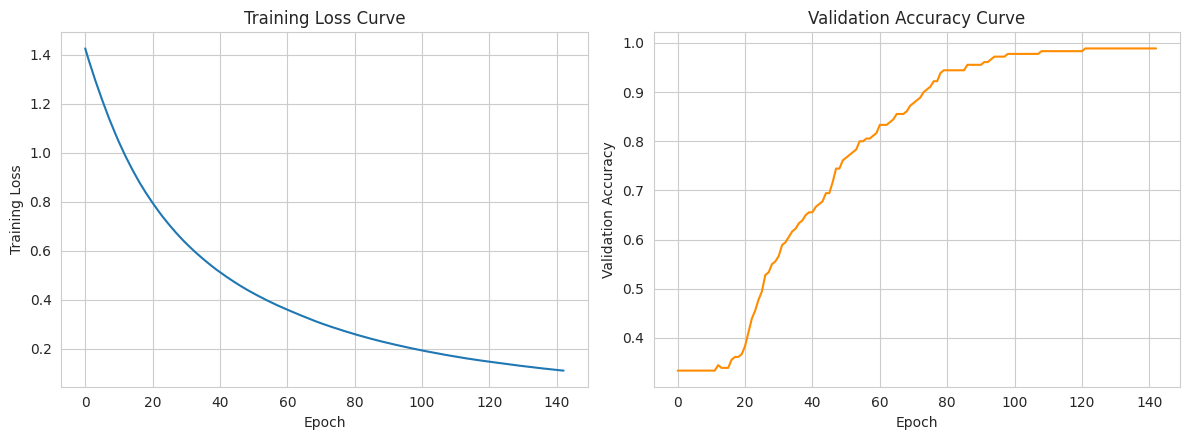

Stopped at epoch: 143 | Test accuracy: 0.9867


In [17]:
curve_model = MLPClassifier(
    hidden_layer_sizes=best_layers,
    activation="relu",
    solver="adam",
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=RANDOM_STATE
)
curve_model.fit(X_train_scaled, y_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(curve_model.loss_curve_)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("Training Loss Curve")

axes[1].plot(curve_model.validation_scores_, color="darkorange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_title("Validation Accuracy Curve")

plt.tight_layout()
plt.show()

test_acc_curve_model = accuracy_score(y_test, curve_model.predict(X_test_scaled))
print(f"Stopped at epoch: {curve_model.n_iter_} | Test accuracy: {test_acc_curve_model:.4f}")


## 11. การทำนายผล (Predictions)

แสดงตัวอย่างผลการทำนายจาก test set เทียบกับค่าจริง และบันทึกผลลัพธ์ทั้งหมดเป็นไฟล์ CSV

In [18]:
results_df = X_test.copy()
results_df["actual"] = y_test.map({1: "Genuine", 0: "Fake"}).values
results_df["predicted"] = pd.Series(y_pred, index=y_test.index).map({1: "Genuine", 0: "Fake"}).values
results_df["genuine_probability"] = np.round(y_proba, 4)
results_df["correct"] = results_df["actual"] == results_df["predicted"]

results_df.to_csv("predictions.csv", index=False)
results_df.head(15)


,diagonal,height_left,height_right,margin_low,margin_up,length,actual,predicted,genuine_probability,correct
803,171.87,103.27,104.50,3.85,3.03,113.19,Genuine,Genuine,0.9914,True
1306,172.13,103.99,104.06,5.80,3.28,111.30,Fake,Fake,0.0000,True
1263,171.59,104.05,104.40,5.05,3.45,111.14,Fake,Fake,0.0000,True
38,172.00,103.76,104.27,4.42,3.29,112.67,Genuine,Genuine,0.5699,True
257,172.19,104.03,104.25,4.17,2.81,112.94,Genuine,Genuine,0.9809,True
395,171.82,104.33,103.83,3.92,2.73,112.99,Genuine,Genuine,0.9944,True
834,172.07,103.61,104.34,4.34,2.85,113.03,Genuine,Genuine,0.9851,True
606,171.52,104.52,103.96,3.43,3.01,113.44,Genuine,Genuine,0.9943,True
397,172.15,104.18,103.53,3.92,3.30,113.42,Genuine,Genuine,0.9942,True
11,171.84,104.59,104.00,3.88,3.27,113.08,Genuine,Genuine,0.9448,True


In [19]:
print(f"Total test samples: {len(results_df)}")
print(f"Correct predictions: {results_df['correct'].sum()}")
print(f"Incorrect predictions: {(~results_df['correct']).sum()}")
print(f"Accuracy: {results_df['correct'].mean():.4f}")

print("\nMisclassified samples:")
results_df[~results_df["correct"]]


Total test samples: 300
Correct predictions: 297
Incorrect predictions: 3
Accuracy: 0.9900

Misclassified samples:


,diagonal,height_left,height_right,margin_low,margin_up,length,actual,predicted,genuine_probability,correct
341,171.90,104.21,104.21,4.77,3.38,113.20,Genuine,Fake,0.3654,False
728,171.94,104.11,104.16,4.08,3.35,111.76,Genuine,Fake,0.0459,False
1160,172.39,104.05,104.32,4.13,3.41,112.66,Fake,Genuine,0.5951,False


## 12. สรุปผล (Summary)

| การทดลอง | ผลลัพธ์ |
|---|---|
| Epochs | เพิ่มขึ้น epoch ช่วยให้ accuracy สูงขึ้นจนถึงจุดหนึ่งแล้วเริ่มคงที่ (ดู `epoch_df`) |
| โครงสร้าง (Layers/Neurons) | โครงสร้างที่ซับซ้อนขึ้นไม่ได้ให้ผลดีกว่าเสมอไปสำหรับ dataset ขนาดเล็กนี้ (ดู `arch_df`) |
| โมเดลที่ดีที่สุด | บันทึกไว้ในตัวแปร `best_model` พร้อมผล Accuracy, Confusion Matrix และ ROC curve ด้านบน |

ผลลัพธ์ทั้งหมด (accuracy ของแต่ละ epoch/configuration) ถูกเก็บไว้ในตาราง `epoch_df` และ `arch_df`
ส่วนผลการทำนายทั้งหมดถูกบันทึกไว้ที่ `predictions.csv`

In [20]:
print("=== Epoch comparison ===")
print(epoch_df.to_string(index=False))
print("\n=== Architecture comparison ===")
print(arch_df.to_string(index=False))


=== Epoch comparison ===
 epochs  train_accuracy  test_accuracy  final_loss  n_iter
      5        0.757500       0.756667    0.516422       5
     10        0.930000       0.923333    0.367123      10
     25        0.981667       0.983333    0.153995      25
     50        0.990000       0.983333    0.066815      50
    100        0.990833       0.990000    0.034698     100
    200        0.991667       0.990000    0.026927     156
    300        0.991667       0.990000    0.026927     156

=== Architecture comparison ===
           architecture  hidden_layers  total_neurons  train_accuracy  test_accuracy  final_loss
    1 layer - 8 neurons              1              8        0.990833       0.993333    0.057853
   1 layer - 32 neurons              1             32        0.991667       0.990000    0.026927
   1 layer - 64 neurons              1             64        0.992500       0.986667    0.024128
    2 layers - (32, 16)              2             48        0.994167       0.9866